# 발표 그래프 재현 노트북 (11장)

두 실험을 **같은 5지표 × 같은 4모델**로 평가한다. 수치는 `reports/figure_data.json`
(집계본, 커밋됨)에서 읽으므로 **GPU 없이** 재현된다.

| | 실험 1 — 단계 사다리 | 실험 2 — 노이즈 강건성 |
|---|---|---|
| 데이터 | ACI-Bench test 120건 | 김고은 형태노이즈 100건 |
| x축 | Baseline → 개선1 → 개선2 → 개선3 | 개선3 → +노이즈 방어 규칙 → +Few-shot |
| 공통 | 4개 모델(Qwen2.5-7B/32B, Llama-3.1-8B, Mistral-7B) 평균 + 개별, 판정 = 32B LLM Judge | |

지표 5종: ROUGE-1 · 구역정렬 · 환각률 · 인용 정밀도 · BERTScore
(+ 실험 2는 노이즈 유형별 환각률 분해 1장 추가 = 총 11장)

전체 파이프라인 재현(GPU 필요)은 `docs/eval_ladder_day6.md` 참조.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import scripts.make_figures as mf
from IPython.display import Image, display

data = mf.load_data()
mf.render_all(data)   # docs/figures/ 11장 재생성

[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp1_r1.png
[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp1_sec.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp1_hr.png
[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp1_cite.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp1_bert.png
[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp2_r1.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp2_sec.png
[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp2_hr.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp2_cite.png
[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp2_bert.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/exp2_hr_by_type.png
[figures] 총 11장


## 실험 1 — 단계 사다리 (ACI-Bench test 120건)

### ROUGE-1 — 내용 유사도

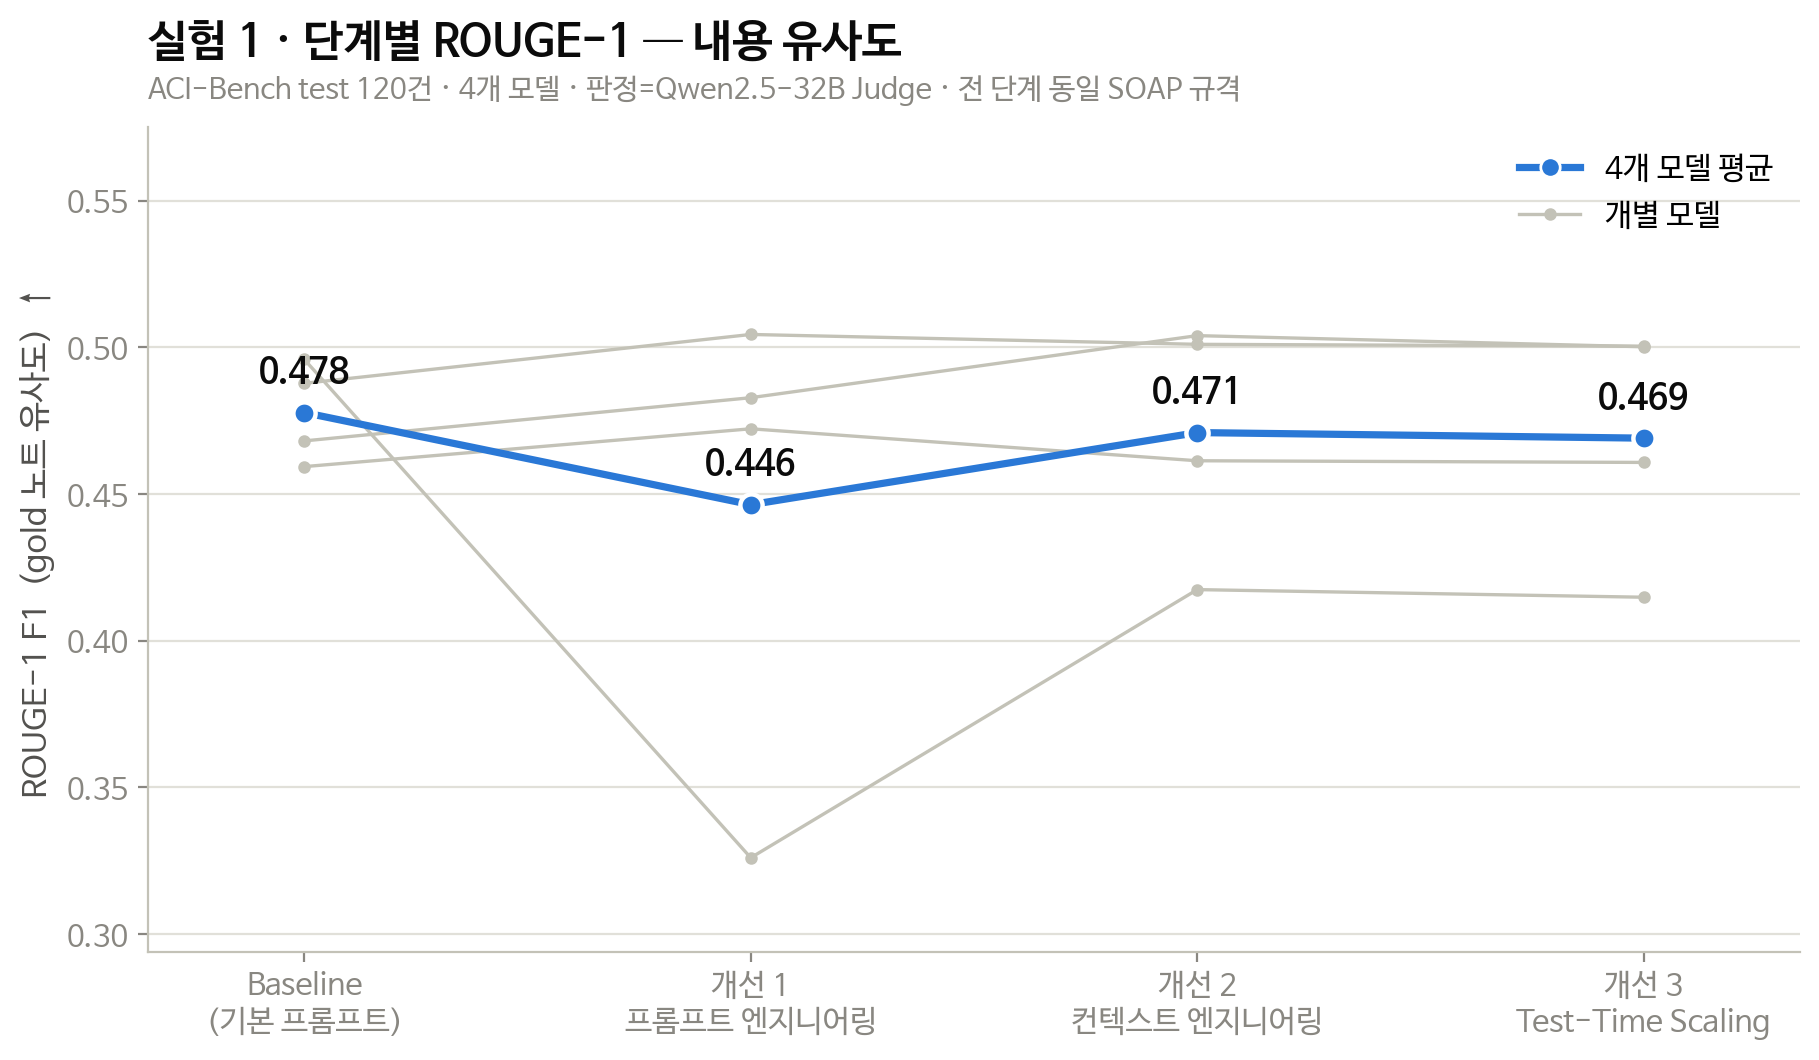

In [2]:
display(Image('../docs/figures/exp1_r1.png', width=860))

### 구역정렬 — 맞는 내용이 맞는 구역에

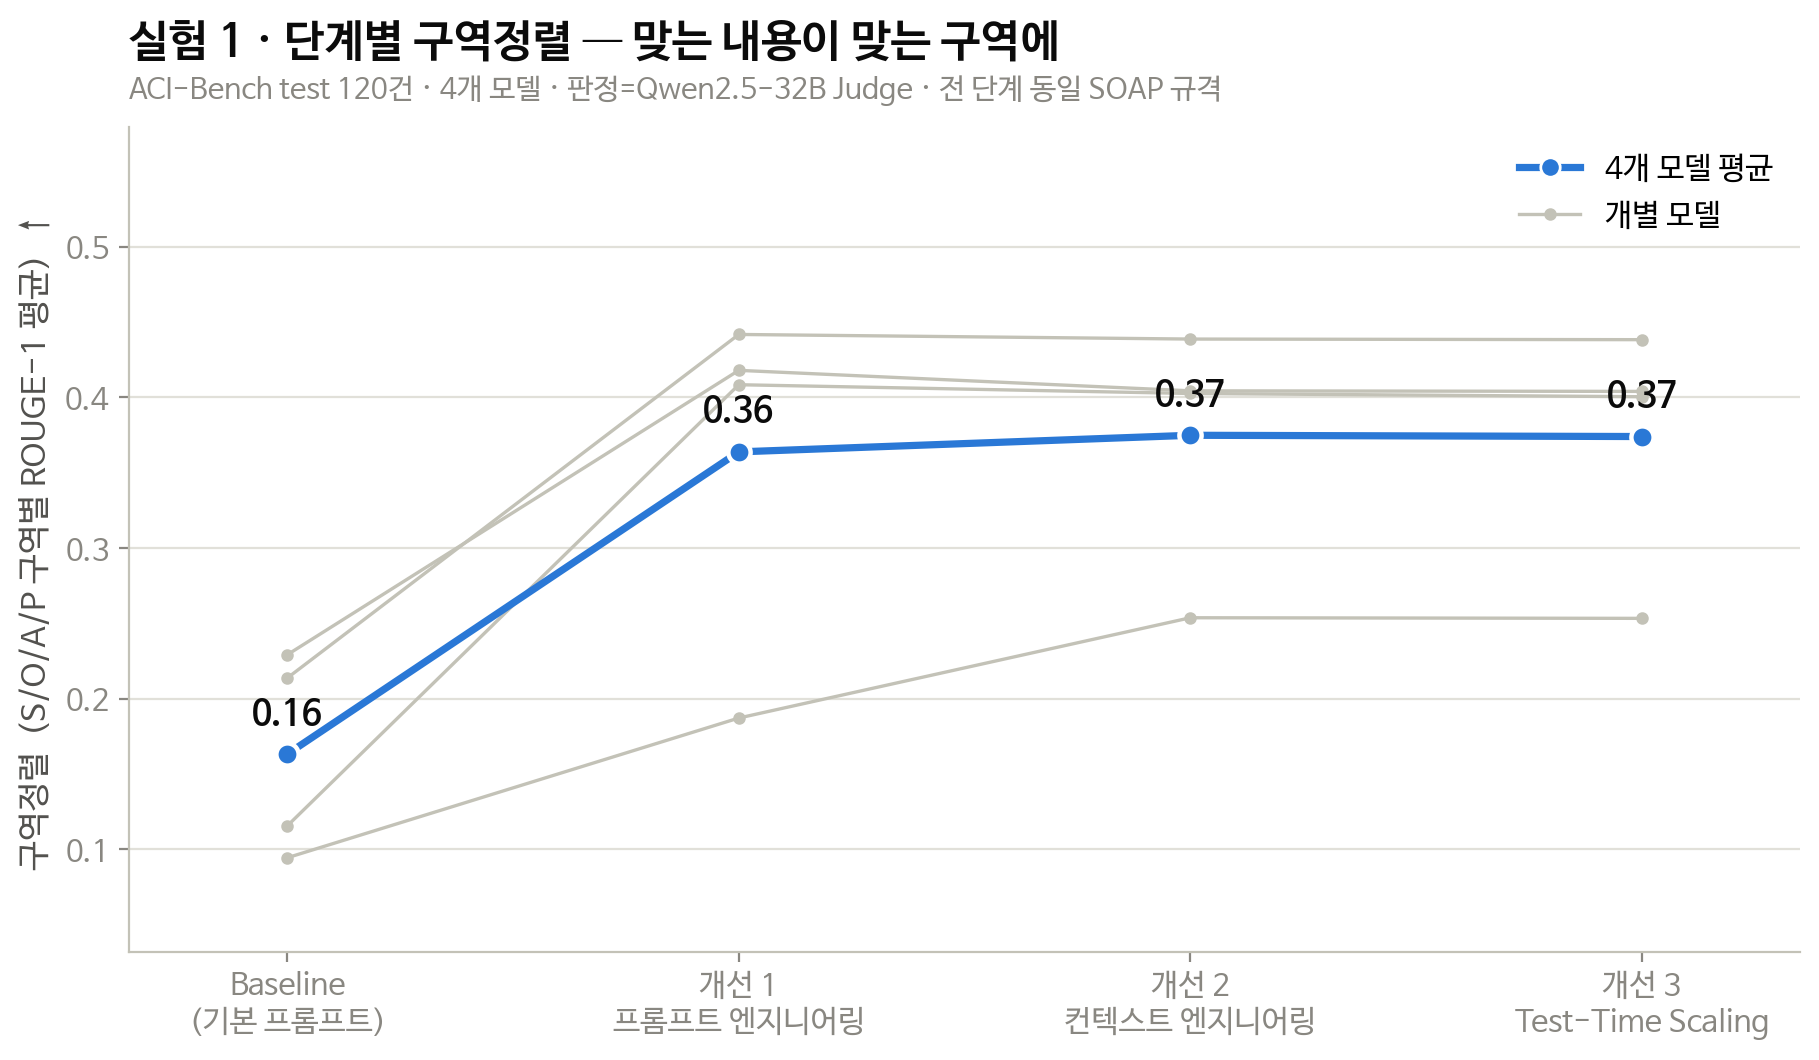

In [3]:
display(Image('../docs/figures/exp1_sec.png', width=860))

### 환각률 — 근거 없는 문장 비율

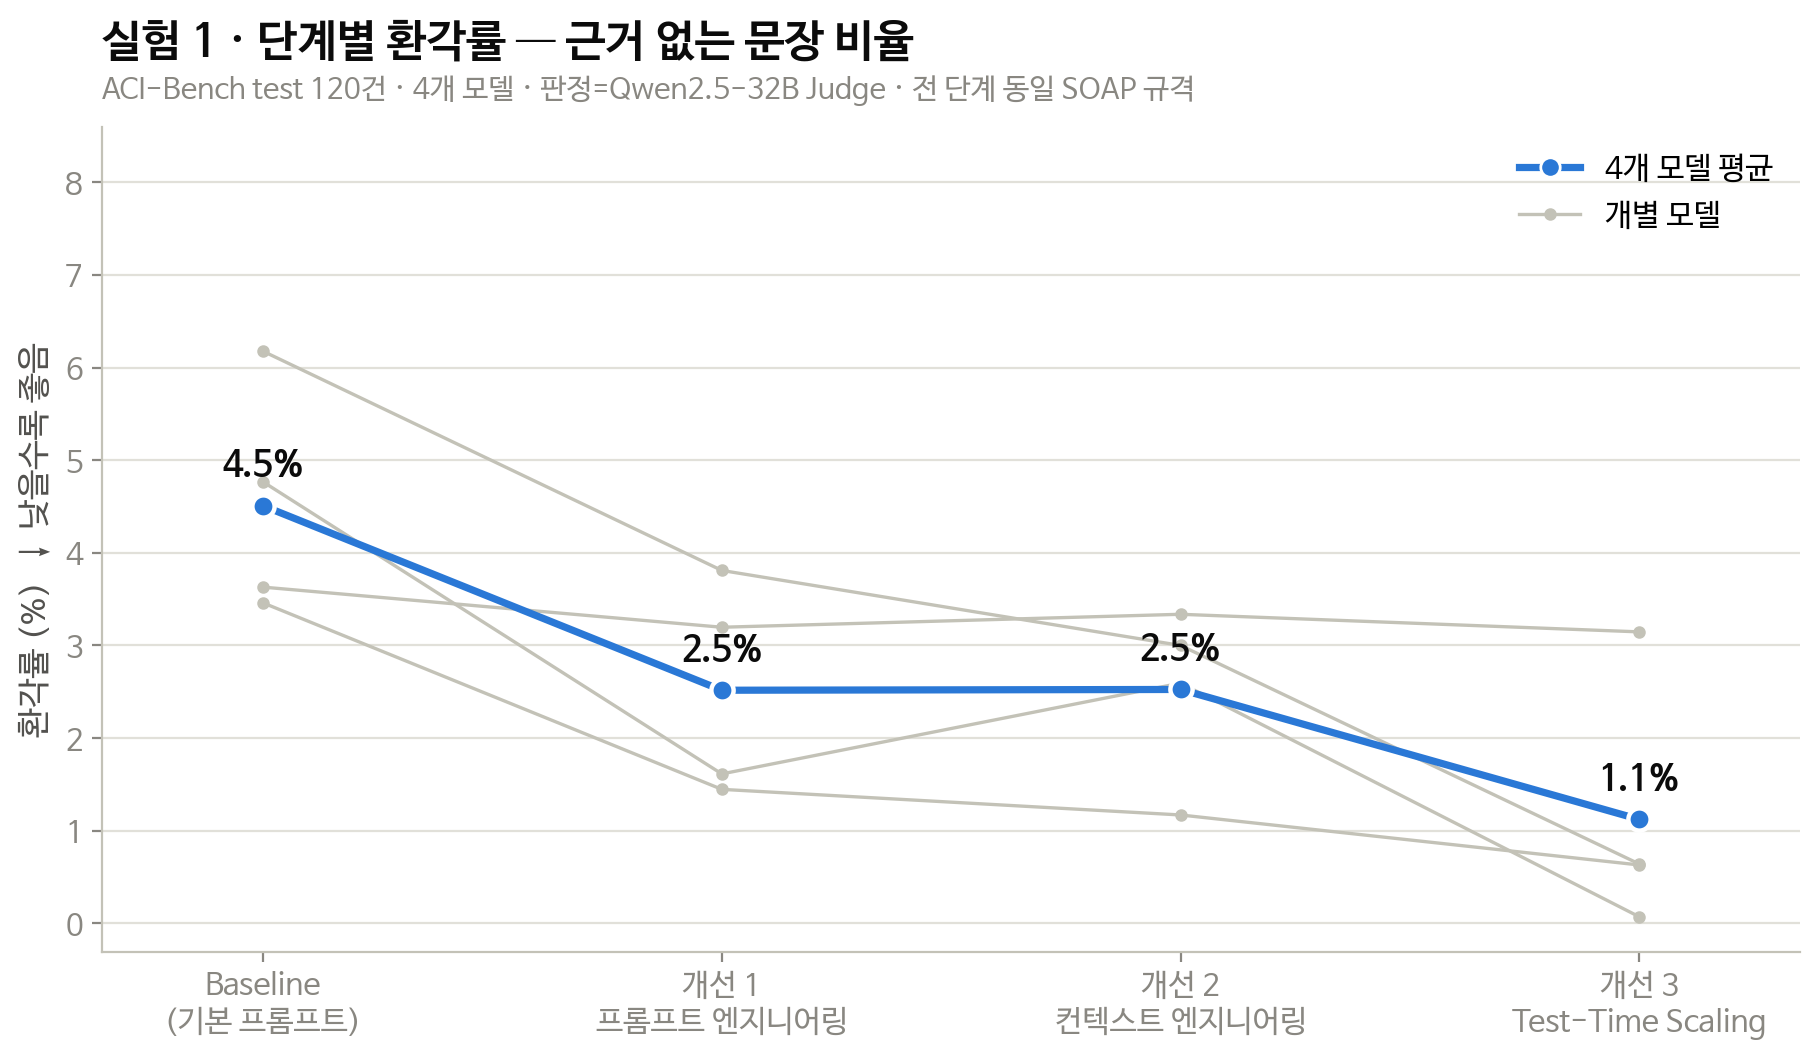

In [4]:
display(Image('../docs/figures/exp1_hr.png', width=860))

### 인용 정밀도

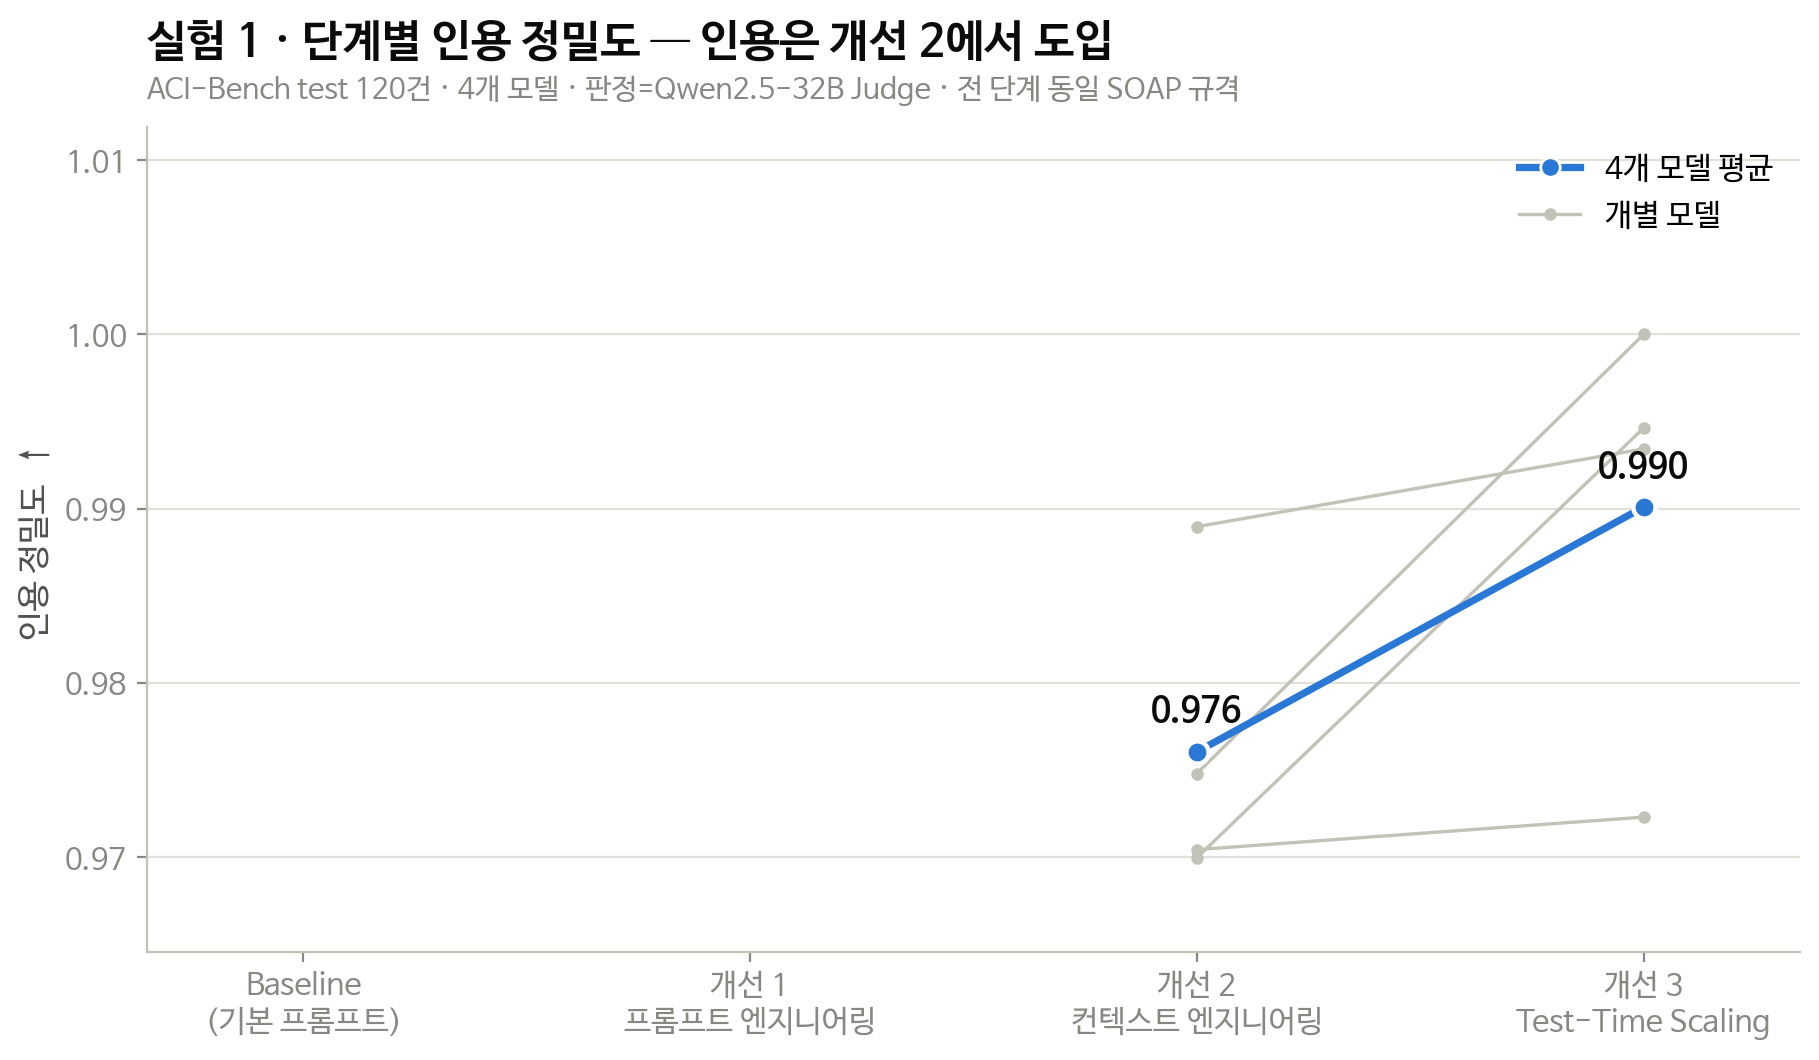

In [5]:
display(Image('../docs/figures/exp1_cite.png', width=860))

### BERTScore — 의미 유사도

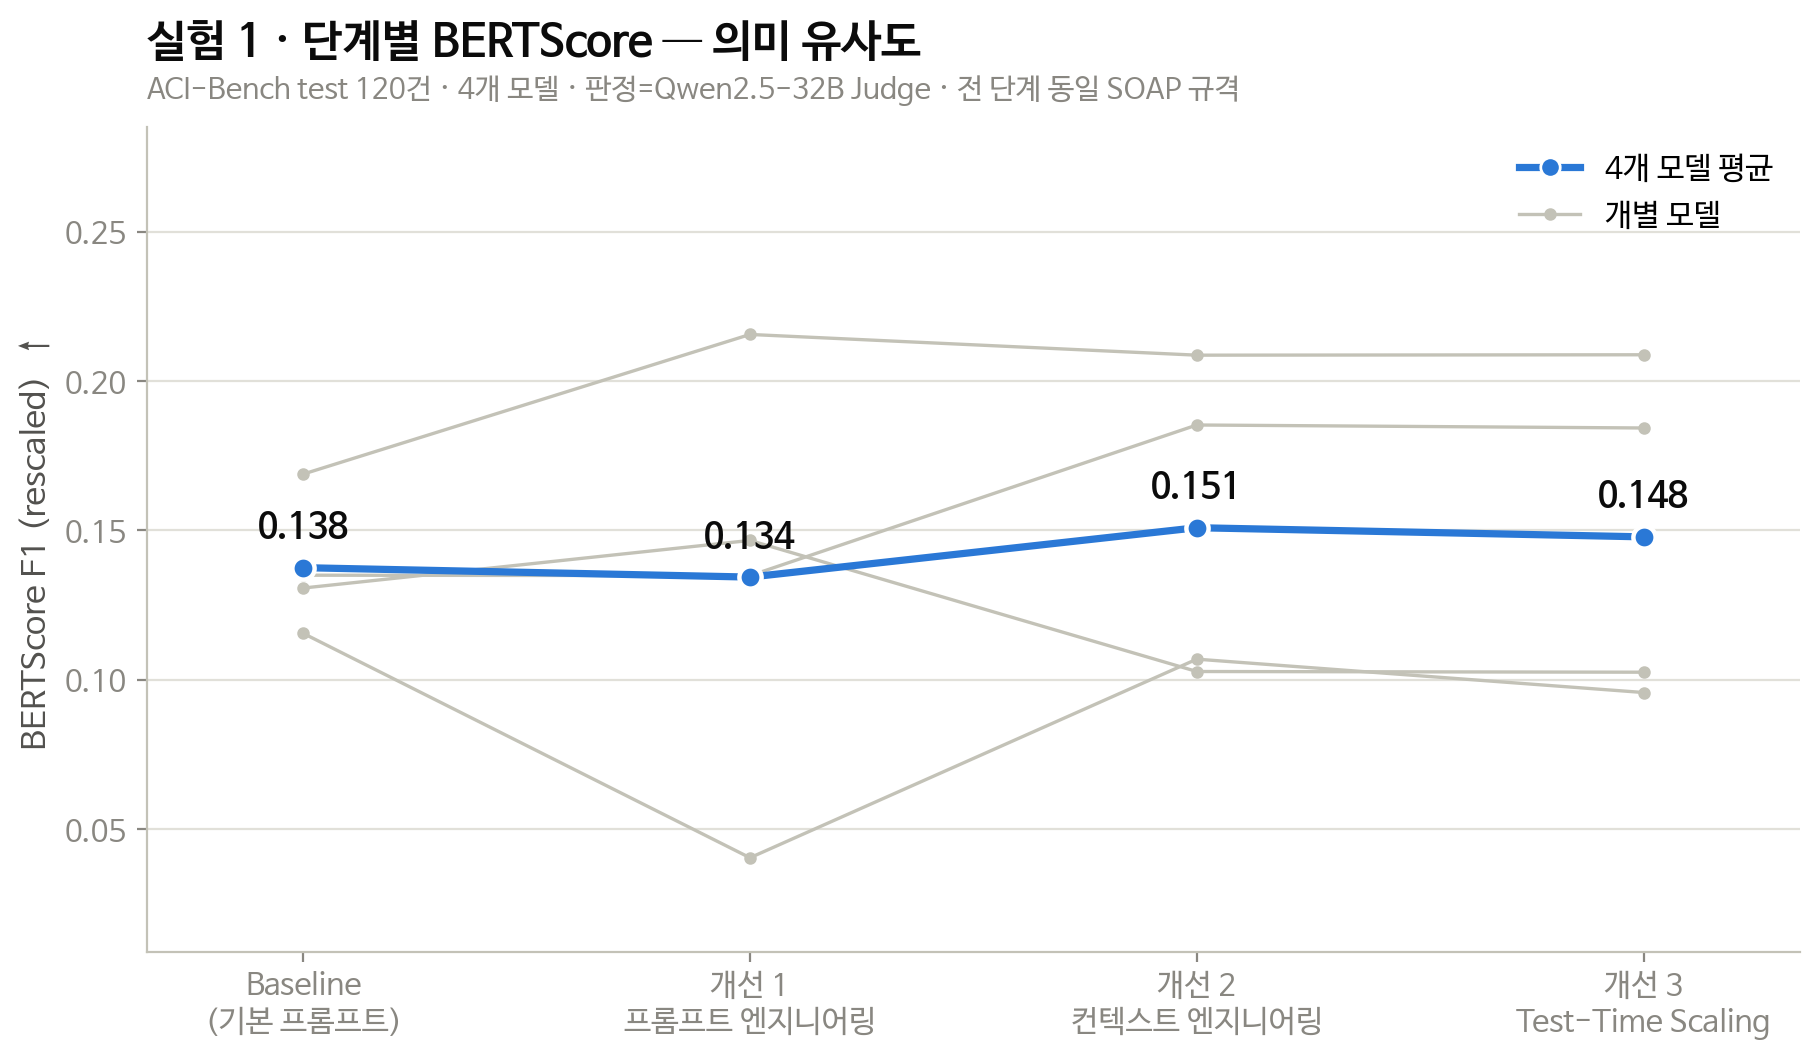

In [6]:
display(Image('../docs/figures/exp1_bert.png', width=860))

## 실험 2 — 노이즈 강건성 (형태노이즈 100건, 세 전략 모두 개선3 교정 적용)

### ROUGE-1 — 내용 유사도

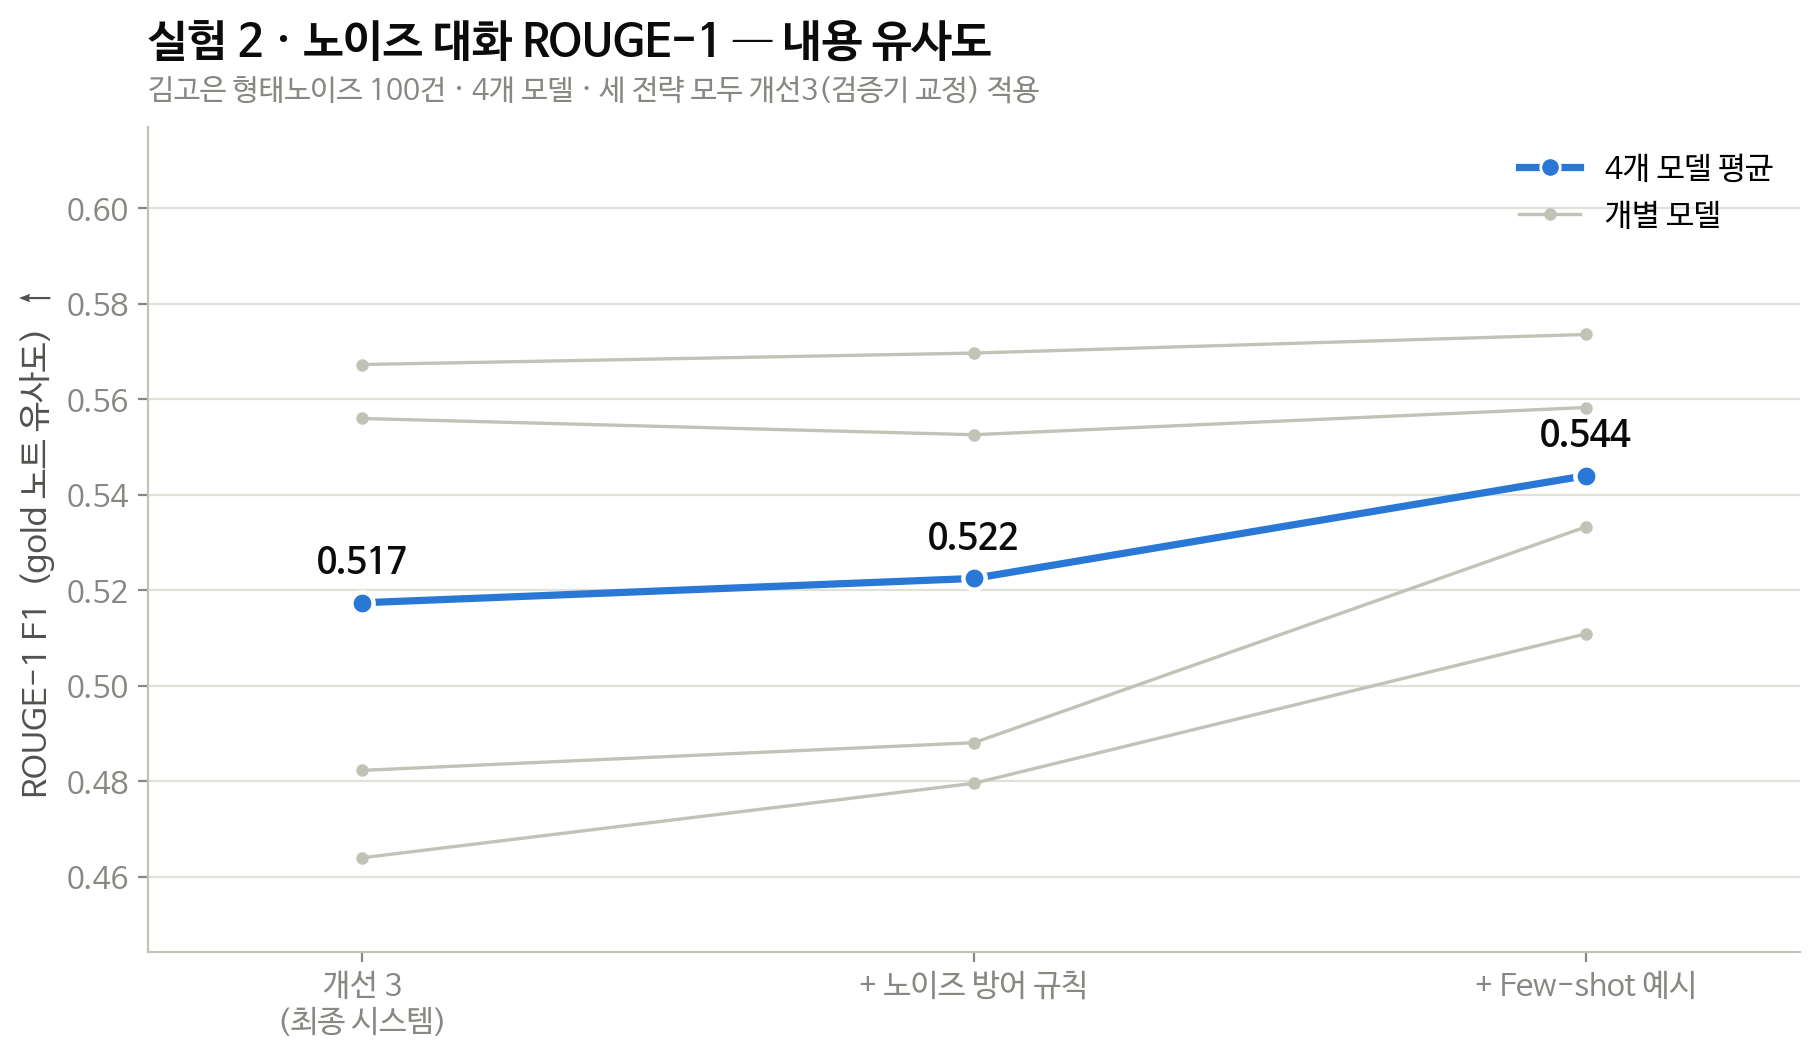

In [7]:
display(Image('../docs/figures/exp2_r1.png', width=860))

### 구역정렬 — 맞는 내용이 맞는 구역에

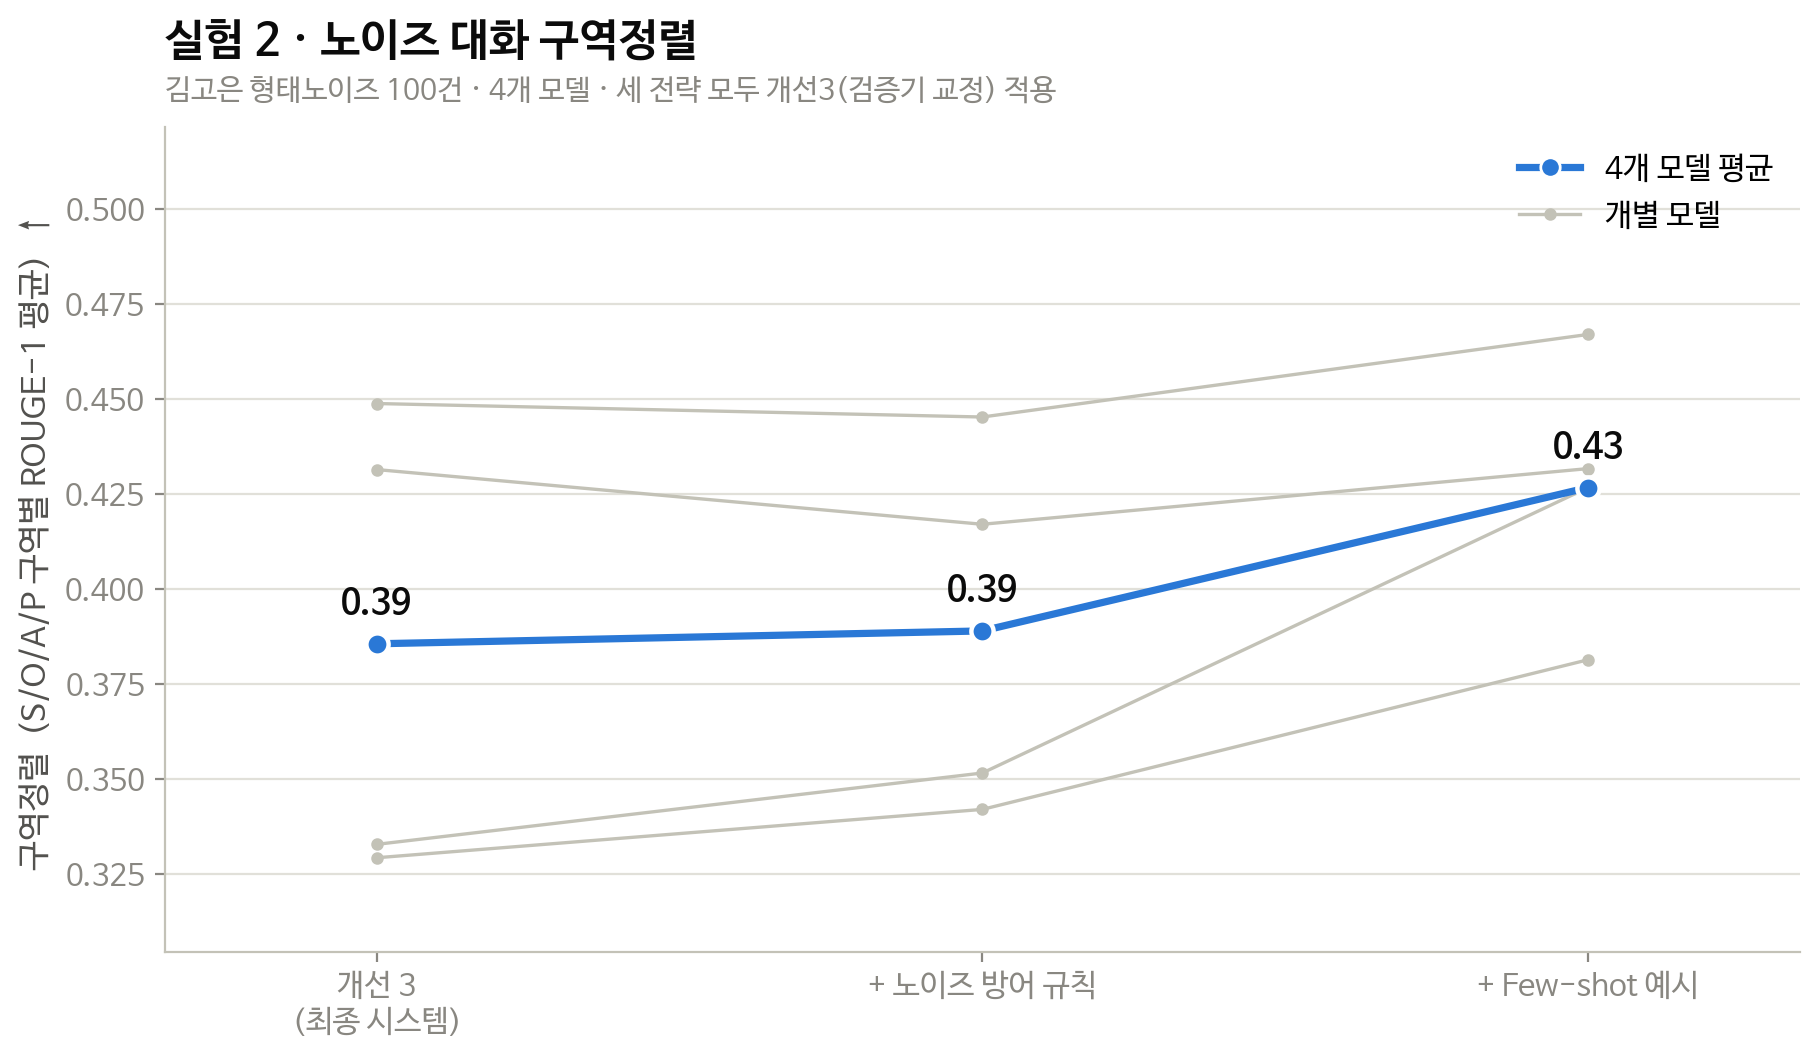

In [8]:
display(Image('../docs/figures/exp2_sec.png', width=860))

### 환각률 — 근거 없는 문장 비율

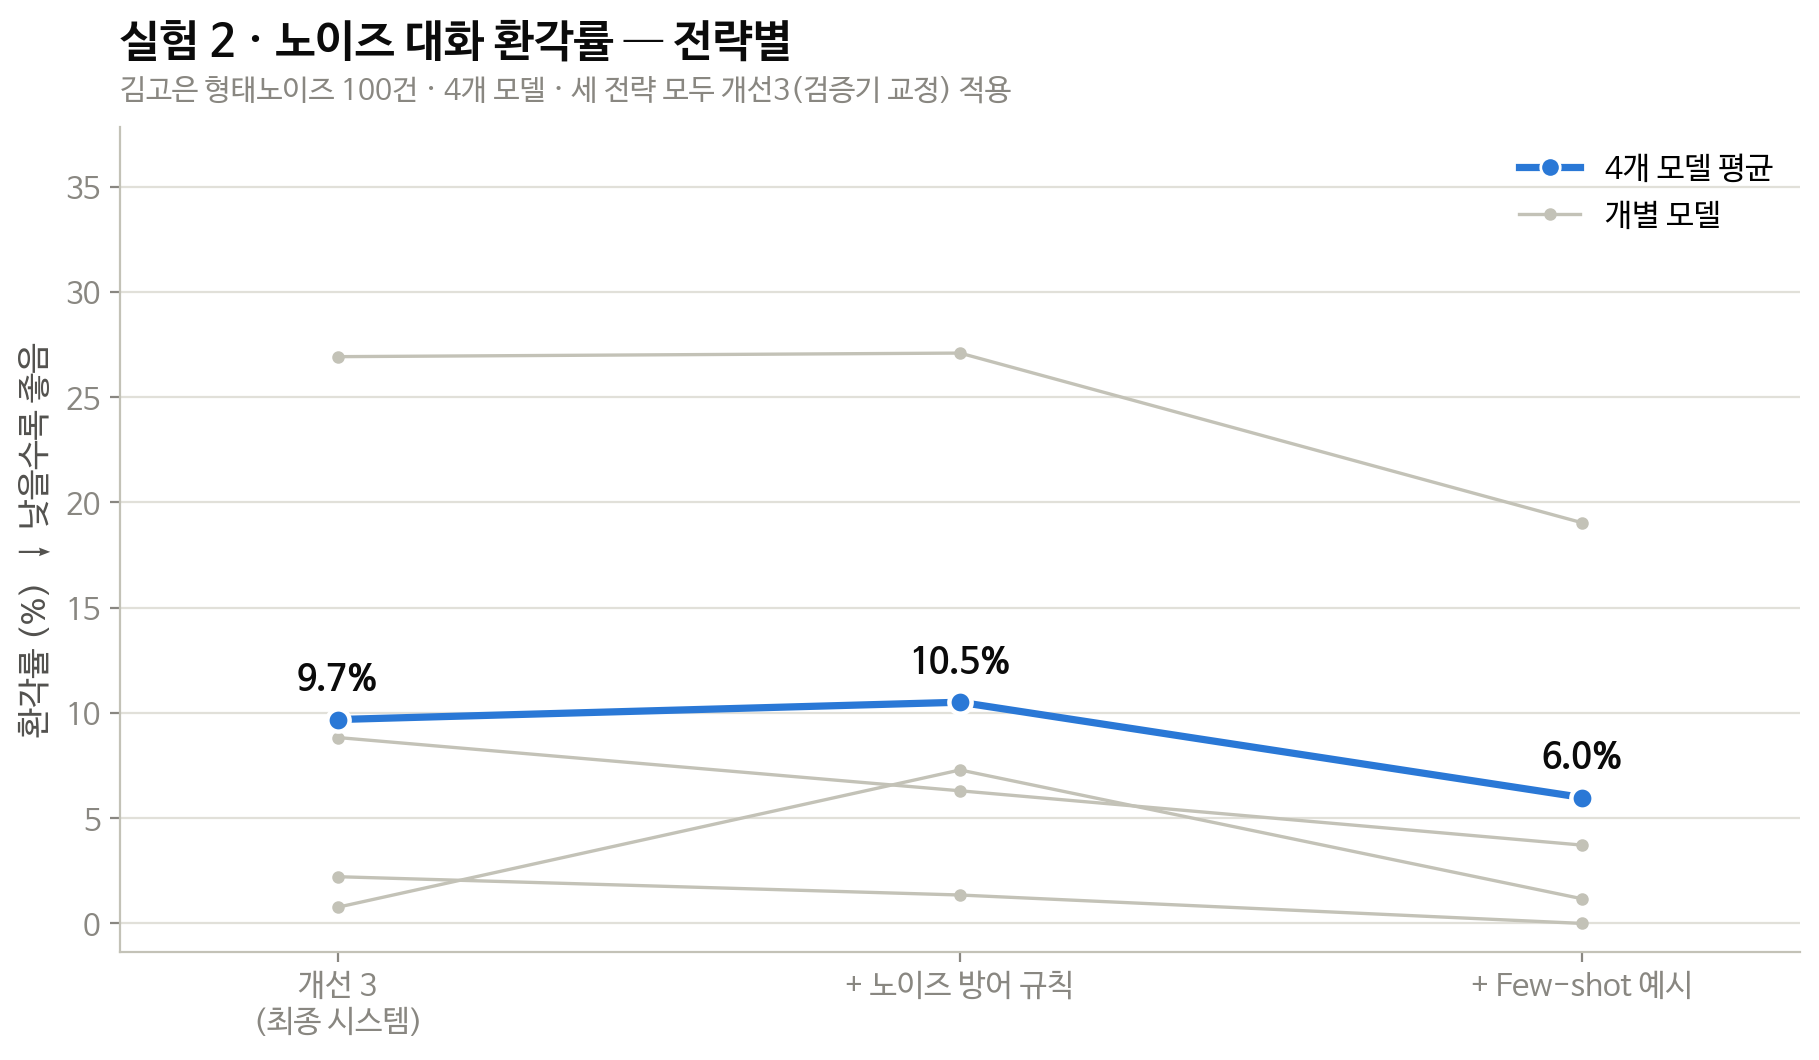

In [9]:
display(Image('../docs/figures/exp2_hr.png', width=860))

### 인용 정밀도

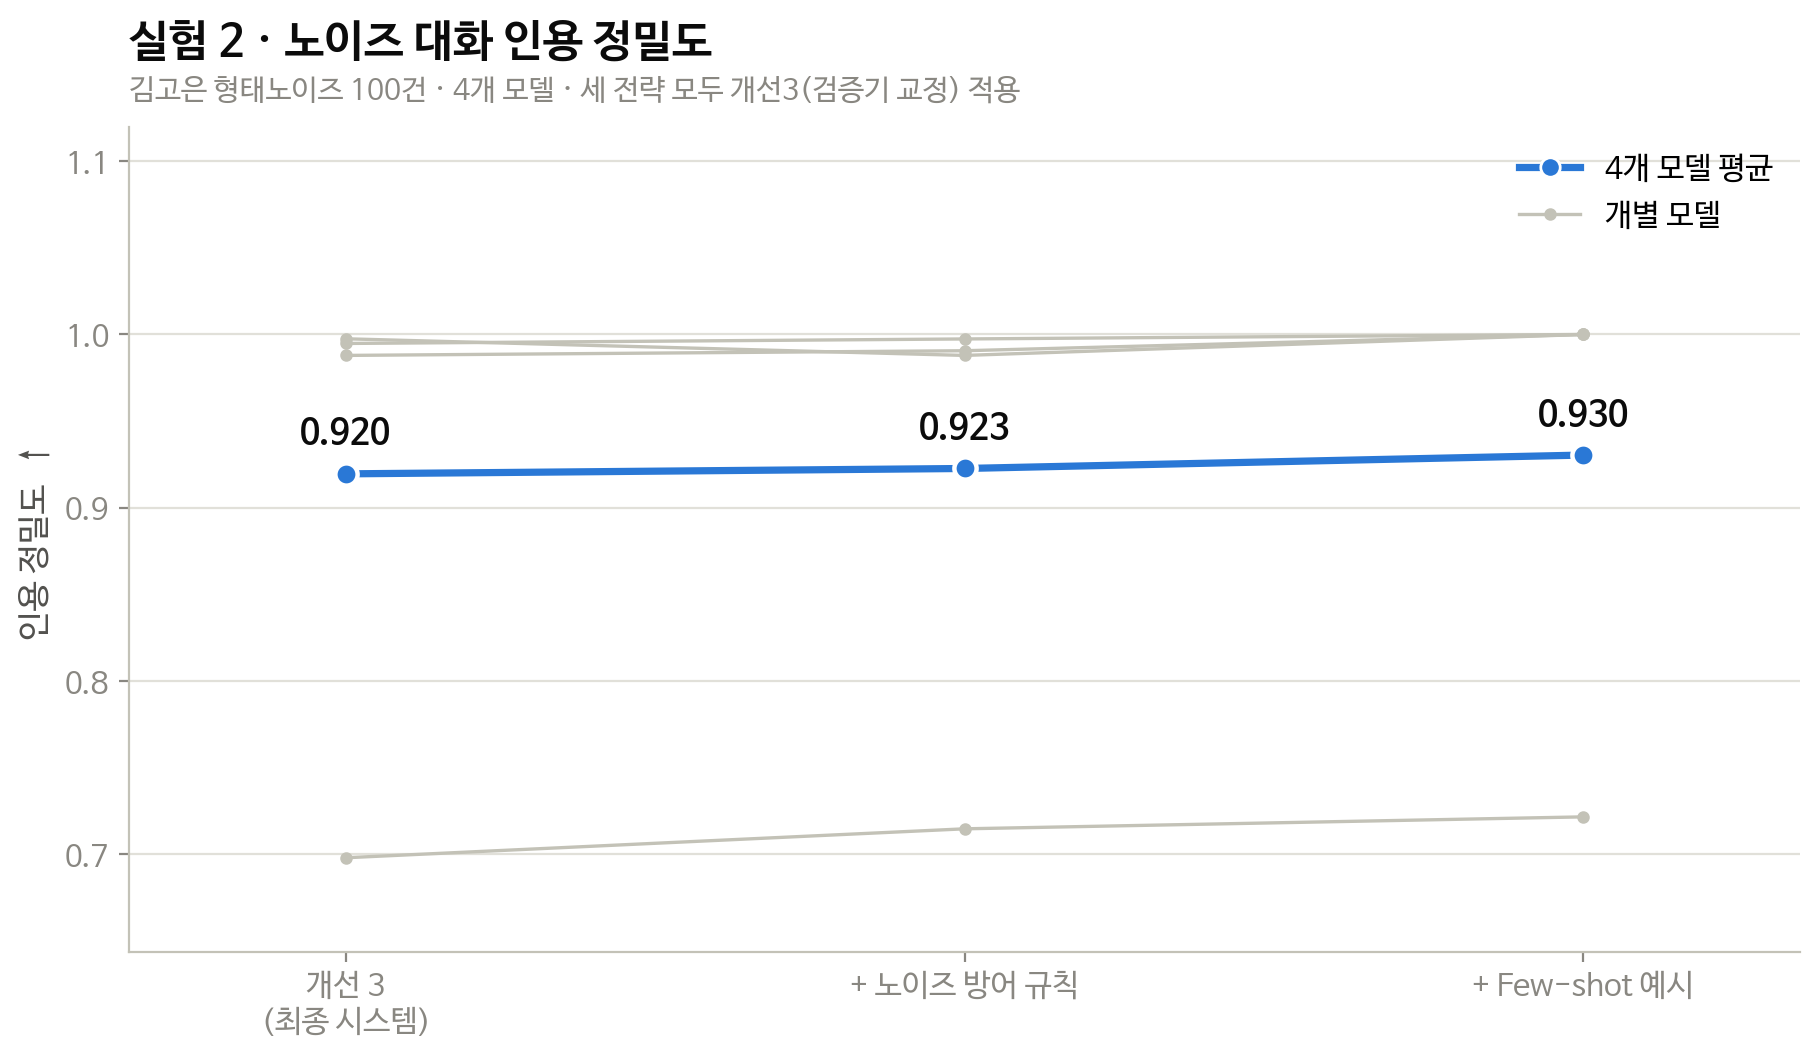

In [10]:
display(Image('../docs/figures/exp2_cite.png', width=860))

### BERTScore — 의미 유사도

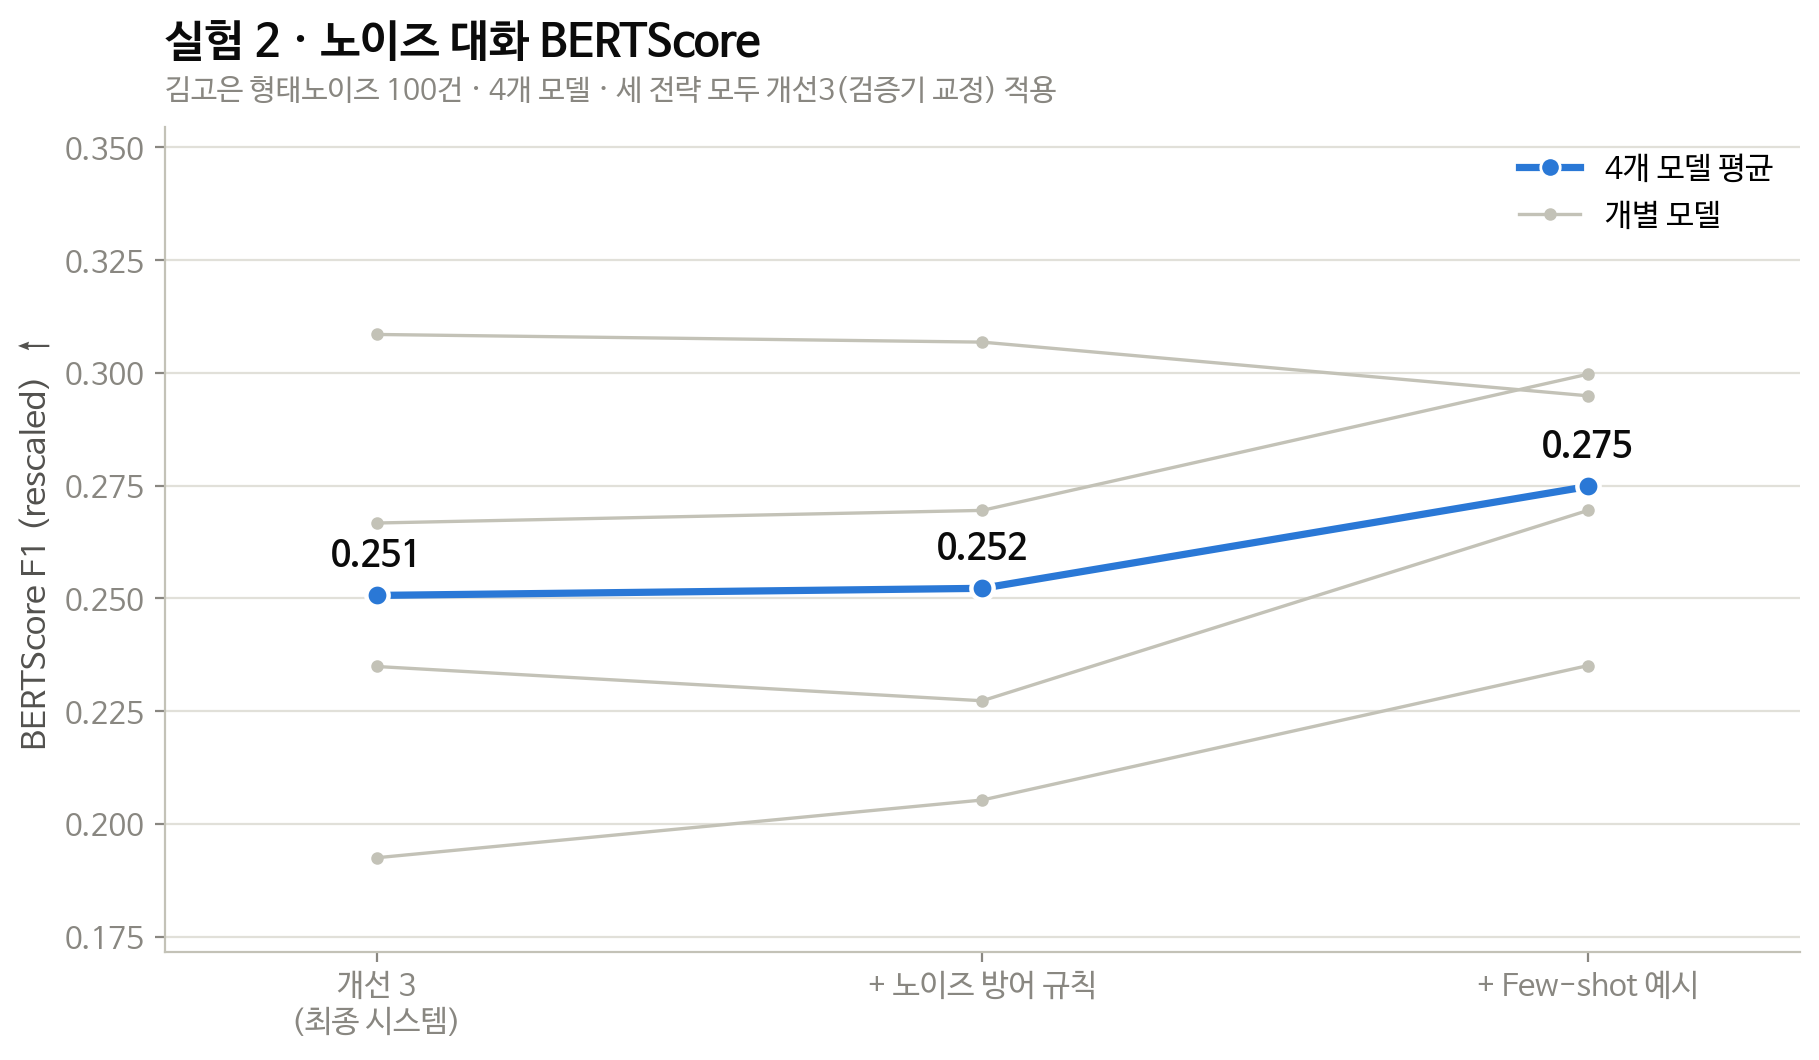

In [11]:
display(Image('../docs/figures/exp2_bert.png', width=860))

### 노이즈 유형별 환각률 — 전략 비교

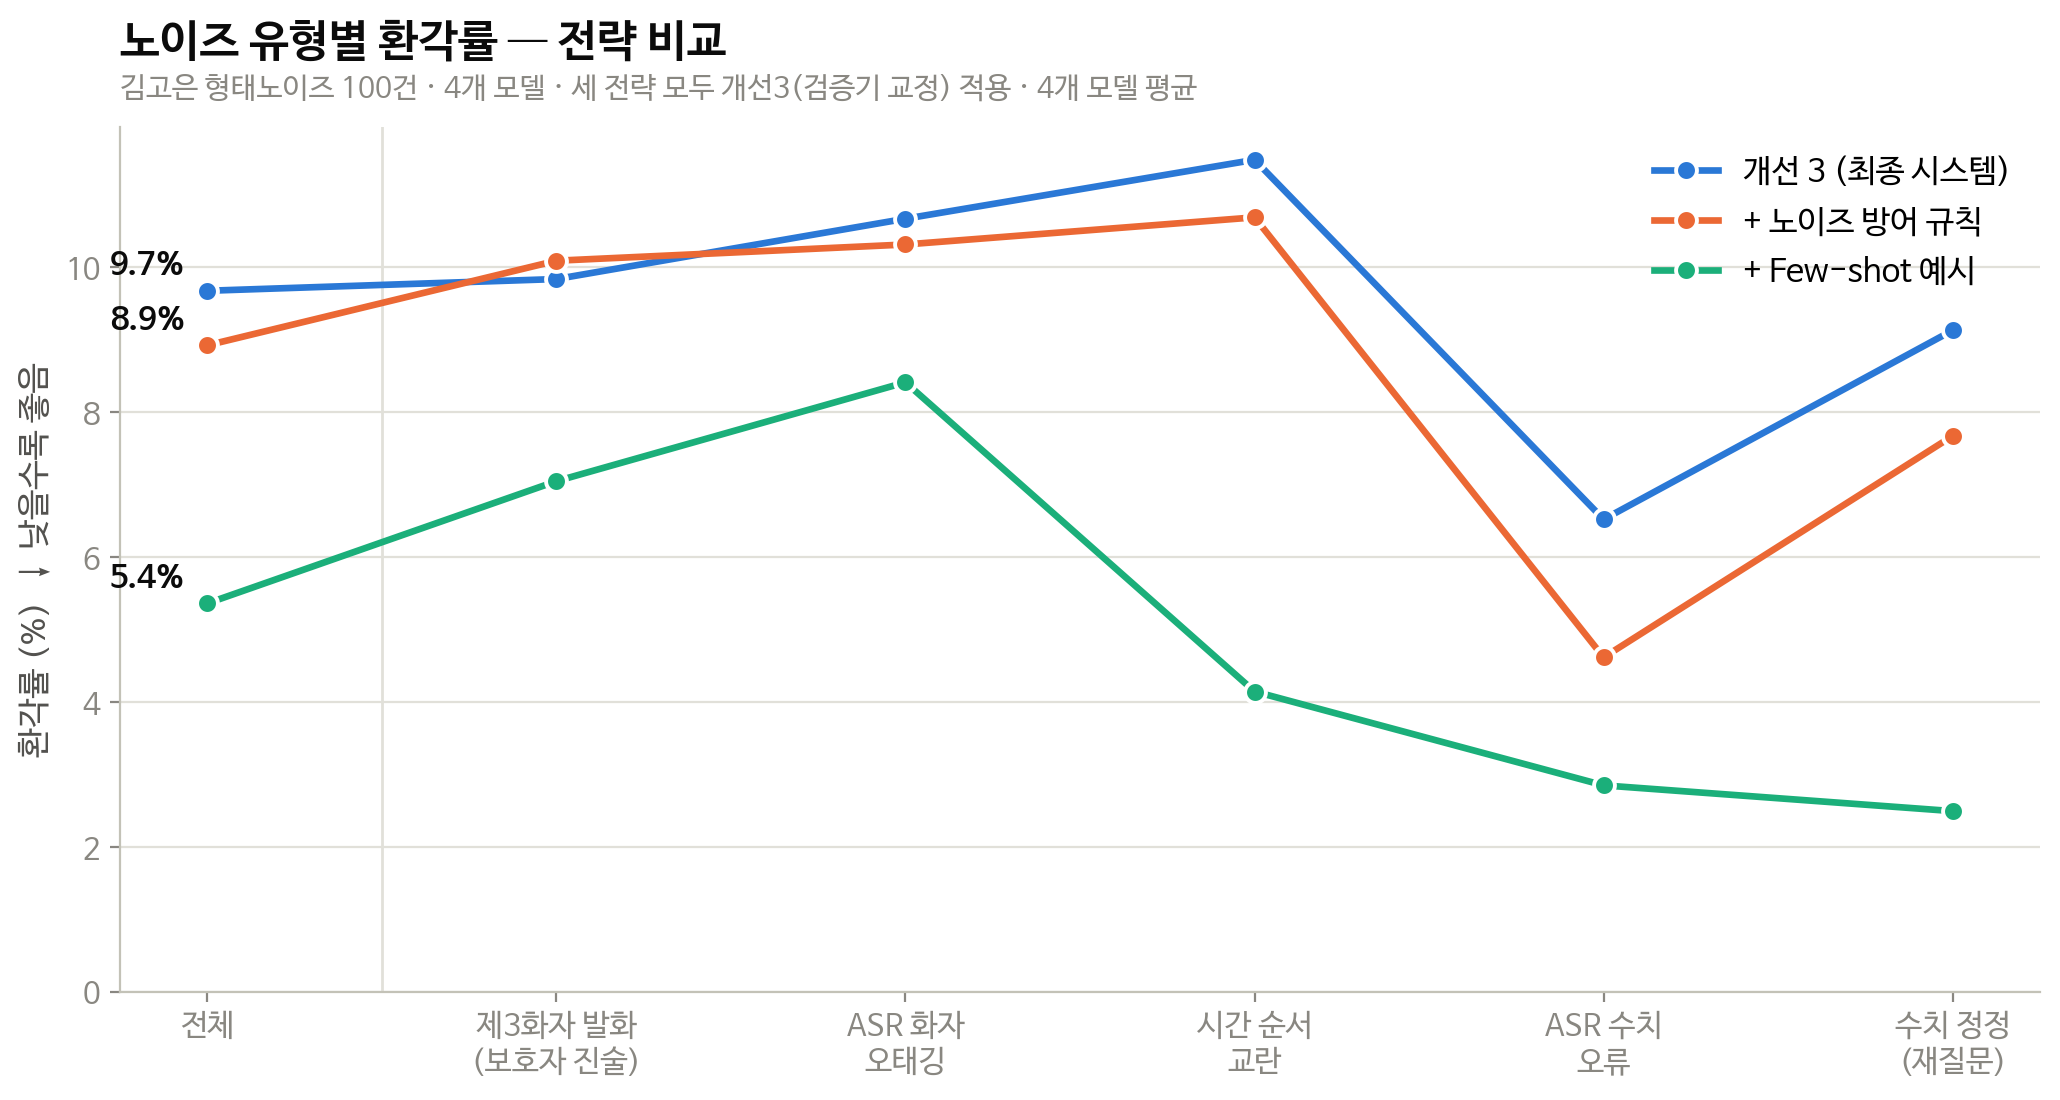

In [12]:
display(Image('../docs/figures/exp2_hr_by_type.png', width=960))

---
### 수치 직접 보기
```python
data['ladder']['hr']        # 실험1: 모델별 환각률 [Baseline, 개선1, 개선2, 개선3]
data['noise']['r1']         # 실험2: 모델별 ROUGE-1 [개선3, +규칙, +few-shot]
data['noise_by_type']       # 실험2: 모델×전략×노이즈유형 환각률
```
`outputs/`를 새로 만들었으면(파이프라인 재실행) 터미널에서:
```bash
.venv/bin/python scripts/make_figures.py --rebuild
```